//EDA - Pilar Munoz

Objetivo: Predecir si un vuelo tendrá retraso (Delay = 1) o no tendrá retraso (Delay = 0).

Fuente:
OpenML / DataHub Airlines Dataset
https://datahub.io/core/openml-datasets/data/airlines?utm_source=chatgpt.com

Preguntas de Negocio para considerar en la exploracion
1. Qué aerolíneas presentan más retrasos?
2. Qué días tienen más retrasos?
3. La hora afecta los retrasos?
4. La duración influye?



1. Librerias, Carga del dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/airlines.csv")
df.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269,SFO,IAH,3,15,205,1
1,US,1558,PHX,CLT,3,15,222,1
2,AA,2400,LAX,DFW,3,20,165,1
3,AA,2466,SFO,DFW,3,20,195,1
4,AS,108,ANC,SEA,3,30,202,0


2. Inspeccion Inicial: Estadisticas descriptivas, valores nulos, duplicados

In [2]:
df.shape

(539383, 8)

In [3]:
df.columns

Index(['Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time',
       'Length', 'Delay'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Airline      539383 non-null  str  
 1   Flight       539383 non-null  int64
 2   AirportFrom  539383 non-null  str  
 3   AirportTo    539383 non-null  str  
 4   DayOfWeek    539383 non-null  int64
 5   Time         539383 non-null  int64
 6   Length       539383 non-null  int64
 7   Delay        539383 non-null  int64
dtypes: int64(5), str(3)
memory usage: 32.9 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Airline,539383,18,WN,94097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight,539383.0,NaN,NaN,NaN,2427.92863,2067.429837,1.0,712.0,1809.0,3745.0,7814.0
AirportFrom,539383,293,ATL,34449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AirportTo,539383,293,ATL,34440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DayOfWeek,539383.0,NaN,NaN,NaN,3.929668,1.914664,1.0,2.0,4.0,5.0,7.0
Time,539383.0,NaN,NaN,NaN,802.728963,278.045911,10.0,565.0,795.0,1035.0,1439.0
Length,539383.0,NaN,NaN,NaN,132.202007,70.117016,0.0,81.0,115.0,162.0,655.0
Delay,539383.0,NaN,NaN,NaN,0.445442,0.497015,0.0,0.0,0.0,1.0,1.0


In [6]:
df.isnull().sum().sort_values(ascending=False)

Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

In [7]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df)

pd.Series(
    {
        "Filas repetidas": duplicate_count,
        "Porcentaje": f"{duplicate_percentage:.2%}",
    },
    name="Duplicados exactos",
)

Filas repetidas    216618
Porcentaje         40.16%
Name: Duplicados exactos, dtype: object

In [8]:
df.nunique().sort_values().rename("Valores unicos").to_frame()

,Valores unicos
Delay,2
DayOfWeek,7
Airline,18
AirportFrom,293
AirportTo,293
Length,426
Time,1131
Flight,6585


In [9]:
quality_checks = pd.Series(
    {
        "Duracion menor o igual a cero": (df["Length"] <= 0).sum(),
        "Hora fuera de 0-1439": (~df["Time"].between(0, 1439)).sum(),
        "Dia fuera de 1-7": (~df["DayOfWeek"].between(1, 7)).sum(),
        "Origen igual al destino": (df["AirportFrom"] == df["AirportTo"]).sum(),
        "Numero de vuelo no positivo": (df["Flight"] <= 0).sum(),
        "Delay fuera de 0-1": (~df["Delay"].isin([0, 1])).sum(),
    },
    name="Registros que incumplen",
)

quality_checks.to_frame()

,Registros que incumplen
Duracion menor o igual a cero,4
Hora fuera de 0-1439,0
Dia fuera de 1-7,0
Origen igual al destino,0
Numero de vuelo no positivo,0
Delay fuera de 0-1,0


### Hallazgos de la inspeccion inicial

- El dataset contiene 539,383 registros y 8 variables.
- No se encontraron valores nulos.
- Hay 216,618 filas repetidas (40.16%). No se eliminan automaticamente porque el dataset no incluye una fecha completa ni un identificador unico que permita confirmar que representan el mismo vuelo.
- Las variables presentan rangos validos, excepto 4 registros con una duracion menor o igual a cero, que debe tomarse una decision en la fase de limpieza.

## 3. Analisis univariado: variables numericas y categoricas

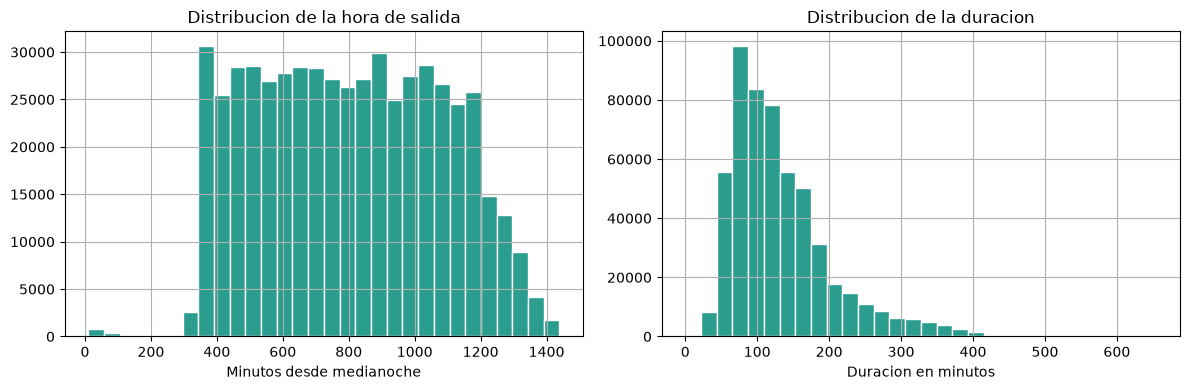

In [15]:
numeric_columns = ["Time", "Length"]

axes = df[numeric_columns].hist(
    bins=30,
    figsize=(12, 4),
    color="#2A9D8F",
    edgecolor="white",
)
axes[0, 0].set(title="Distribucion de la hora de salida", xlabel="Minutos desde medianoche")
axes[0, 1].set(title="Distribucion de la duracion", xlabel="Duracion en minutos")
plt.tight_layout()
plt.show()

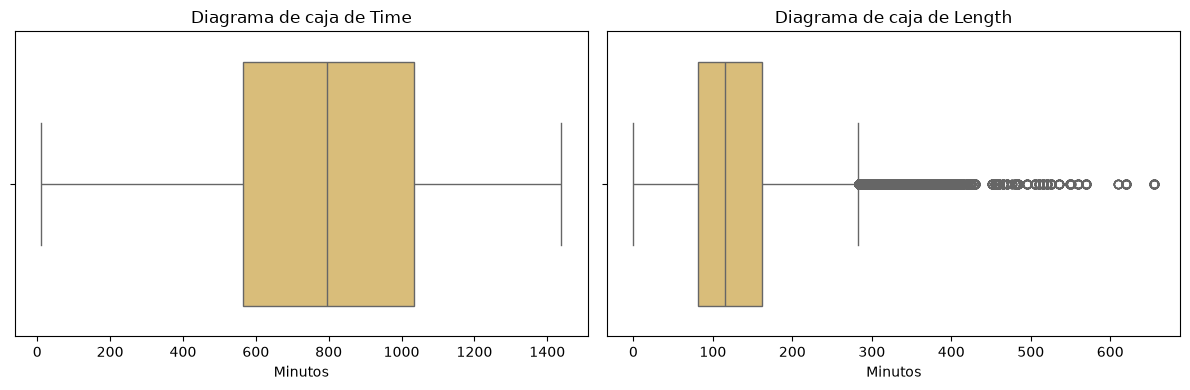

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for axis, column in zip(axes, numeric_columns):
    sns.boxplot(x=df[column], ax=axis, color="#E9C46A")
    axis.set(
        title=f"Diagrama de caja de {column}",
        xlabel="Minutos",
    )

plt.tight_layout()
plt.show()

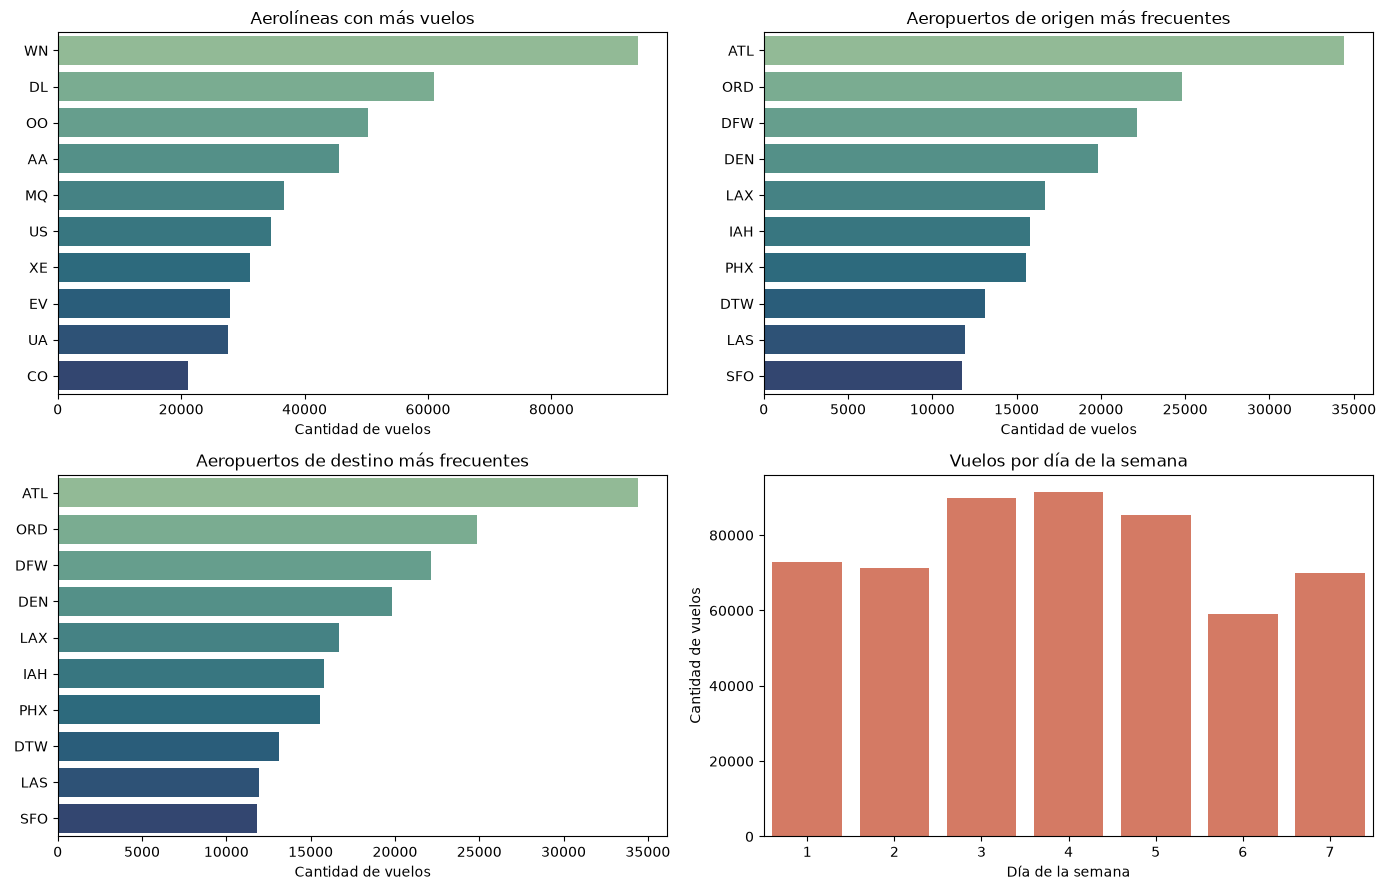

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

categorical_plots = {
    "Airline": "Aerolíneas con más vuelos",
    "AirportFrom": "Aeropuertos de origen más frecuentes",
    "AirportTo": "Aeropuertos de destino más frecuentes",
}

for axis, (column, title) in zip(axes.flat[:3], categorical_plots.items()):
    counts = df[column].value_counts().head(10)
    sns.barplot(
        x=counts.values,
        y=counts.index,
        hue=counts.index,
        palette="crest",
        legend=False,
        ax=axis,
    )
    axis.set(title=title, xlabel="Cantidad de vuelos", ylabel="")

day_counts = df["DayOfWeek"].value_counts().sort_index()
sns.barplot(
    x=day_counts.index,
    y=day_counts.values,
    color="#E76F51",
    ax=axes[1, 1],
)
axes[1, 1].set(
    title="Vuelos por día de la semana",
    xlabel="Día de la semana",
    ylabel="Cantidad de vuelos",
)

plt.tight_layout()
plt.show()

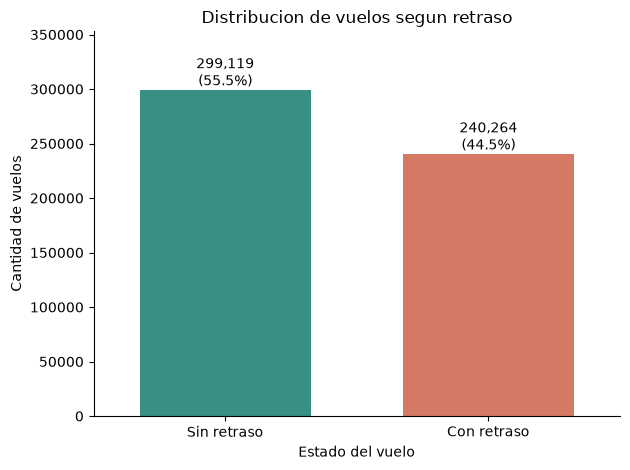

In [18]:
delay_counts = df["Delay"].value_counts().sort_index()
delay_labels = ["Sin retraso", "Con retraso"]

ax = sns.barplot(
    x=delay_labels,
    y=delay_counts.values,
    hue=delay_labels,
    palette=["#2A9D8F", "#E76F51"],
    legend=False,
    width=0.65,
 )
ax.set(
    title="Distribucion de vuelos segun retraso",
    xlabel="Estado del vuelo",
    ylabel="Cantidad de vuelos",
)
ax.margins(y=0.18)

for bar, count in zip(ax.patches, delay_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({count / len(df):.1%})",
        ha="center",
        va="bottom",
    )

sns.despine()
plt.tight_layout()
plt.show()

### Hallazgos del analisis univariado

#### Clasificacion de las variables

- **Numericas cuantitativas:** `Time` (minutos transcurridos desde medianoche) y `Length` (duracion del vuelo en minutos). Sus valores representan cantidades, por lo que se analizaron con histogramas, cuartiles y diagramas de caja.
- **Categoricas nominales:** `Airline`, `AirportFrom` y `AirportTo`. Sus valores son etiquetas sin un orden natural, por lo que se analizaron mediante frecuencias.
- **Categorica nominal codificada como numero:** `Flight`. Aunque su tipo es numerico, representa el codigo del vuelo.
- **Categorica ordinal codificada como numero:** `DayOfWeek`. Los valores del 1 al 7 identifican dias y siguen una secuencia.
- **Categorica binaria y variable objetivo:** `Delay`. `0` significa sin retraso y `1` con retraso.

#### Resultados principales

- `Time` presenta una distribucion aproximadamente simetrica. La mediana es 795 minutos despues de medianoche (13:15), y el 50% central de los vuelos sale entre los minutos 565 y 1035 (09:25-17:15).
- `Length` tiene asimetria positiva: la mediana es 115 minutos, el 50% central se encuentra entre 81 y 162 minutos y existe una cola de vuelos largos que llega hasta 655 minutos.
- El boxplot marca numerosos vuelos largos como valores atipicos estadisticos. Esto no significa que sean errores; deben distinguirse de los 4 registros con duracion igual a cero, que si requieren limpieza.
- `WN` es la aerolinea con mayor volumen: 94,097 vuelos (17.45%), seguida por `DL` con 60,940 (11.30%).
- `ATL` es el aeropuerto mas frecuente tanto de origen como de destino, con cerca de 34,400 vuelos (6.39%). Le siguen `ORD`, `DFW`, `DEN` y `LAX`.
- Los dias 3, 4 y 5 concentran la mayor actividad. El dia 4 registra 91,445 vuelos (16.95%), mientras que el dia 6 tiene el menor volumen, con 58,956 (10.93%).
- La variable objetivo esta relativamente equilibrada: 299,119 vuelos (55.46%) no presentan retraso y 240,264 (44.54%) si presentan retraso.

## 4. Deteccion de outliers

In [19]:
outlier_summary = []
outlier_masks = {}

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_mask = ~df[column].between(lower_limit, upper_limit)
    outlier_masks[column] = outlier_mask

    outlier_summary.append(
        {
            "Variable": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Limite inferior": lower_limit,
            "Limite superior": upper_limit,
            "Cantidad de outliers": outlier_mask.sum(),
            "Porcentaje": f"{outlier_mask.mean():.2%}",
        }
    )

pd.DataFrame(outlier_summary).set_index("Variable")

,Q1,Q3,IQR,Limite inferior,Limite superior,Cantidad de outliers,Porcentaje
Variable,,,,,,,
Time,565.0,1035.0,470.0,-140.0,1740.0,0,0.00%
Length,81.0,162.0,81.0,-40.5,283.5,25650,4.76%


In [20]:
length_outliers = df.loc[outlier_masks["Length"]].sort_values(
    "Length", ascending=False
)
invalid_length = df.loc[df["Length"] <= 0]

print(f"Outliers estadisticos en Length: {len(length_outliers):,}")
print(f"Duraciones invalidas (Length <= 0): {len(invalid_length):,}")

display(length_outliers.head(10))
display(invalid_length)

Outliers estadisticos en Length: 25,650
Duraciones invalidas (Length <= 0): 4


,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
477974,CO,15,EWR,HNL,2,815,655,1
411425,CO,15,EWR,HNL,5,815,655,0
338200,CO,15,EWR,HNL,1,815,655,1
24930,CO,15,EWR,HNL,4,710,655,1
247873,CO,15,EWR,HNL,3,710,655,1
194836,CO,15,EWR,HNL,7,710,655,0
514955,CO,15,EWR,HNL,4,815,655,1
110171,CO,15,EWR,HNL,2,710,655,1
7104,CO,15,EWR,HNL,3,710,655,1
267755,CO,15,EWR,HNL,4,815,655,1


,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
179149,F9,106,DEN,MSP,6,635,0,0
182840,F9,107,MSP,DEN,6,851,0,0
188953,F9,103,MSP,DEN,7,375,0,0
445578,B6,493,BOS,SEA,7,1060,0,1


### Hallazgos de la deteccion de outliers

- Se aplico el metodo de Tukey, que considera atipicos los valores inferiores a $Q1 - 1.5 \times IQR$ o superiores a $Q3 + 1.5 \times IQR$. Tukey  usa percentiles (`Q1` y `Q3`), pero define los limites a partir de la dispersion del 50% central, en lugar de marcar siempre un porcentaje fijo de observaciones como ocurriria al usar, por ejemplo, los percentiles 1 y 99.
- `Time` no presenta valores atipicos: sus 539,383 observaciones estan dentro de los limites -140 y 1740.
- Para `Length`, el limite superior es 283.5 minutos. Se identificaron 25,650 vuelos por encima de este valor, equivalentes al 4.76% del dataset.
- Los vuelos largos son atipicos estadisticos, pero varias rutas observadas son plausibles, como `EWR-HNL` con 655 minutos. Se decide no eliminarlos automaticamente.
- Las 4 observaciones con `Length = 0` no son detectadas por el limite IQR inferior; se revisaran durante la limpieza.

## 5. Correlaciones y relaciones con la variable objetivo

En esta seccion se combinan dos enfoques: correlacion para las variables cuantitativas y tasas de retraso para las variables categoricas. `Flight` se excluye de la matriz, `DayOfWeek` se analiza como categoria.

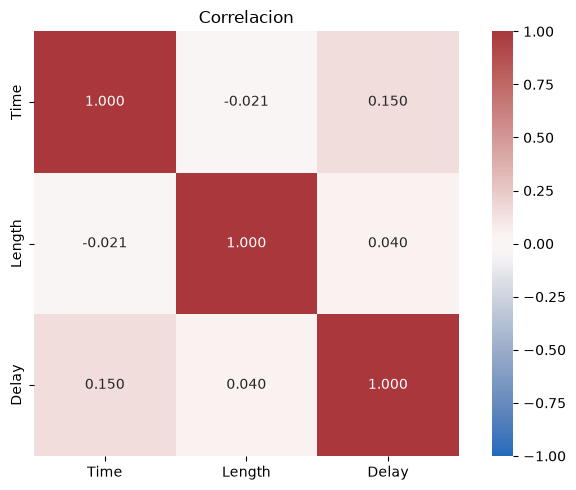

In [24]:
correlation_columns = ["Time", "Length", "Delay"]
correlation_matrix = df[correlation_columns].corr(method="pearson")

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
 )
plt.title("Correlacion")
plt.tight_layout()
plt.show()

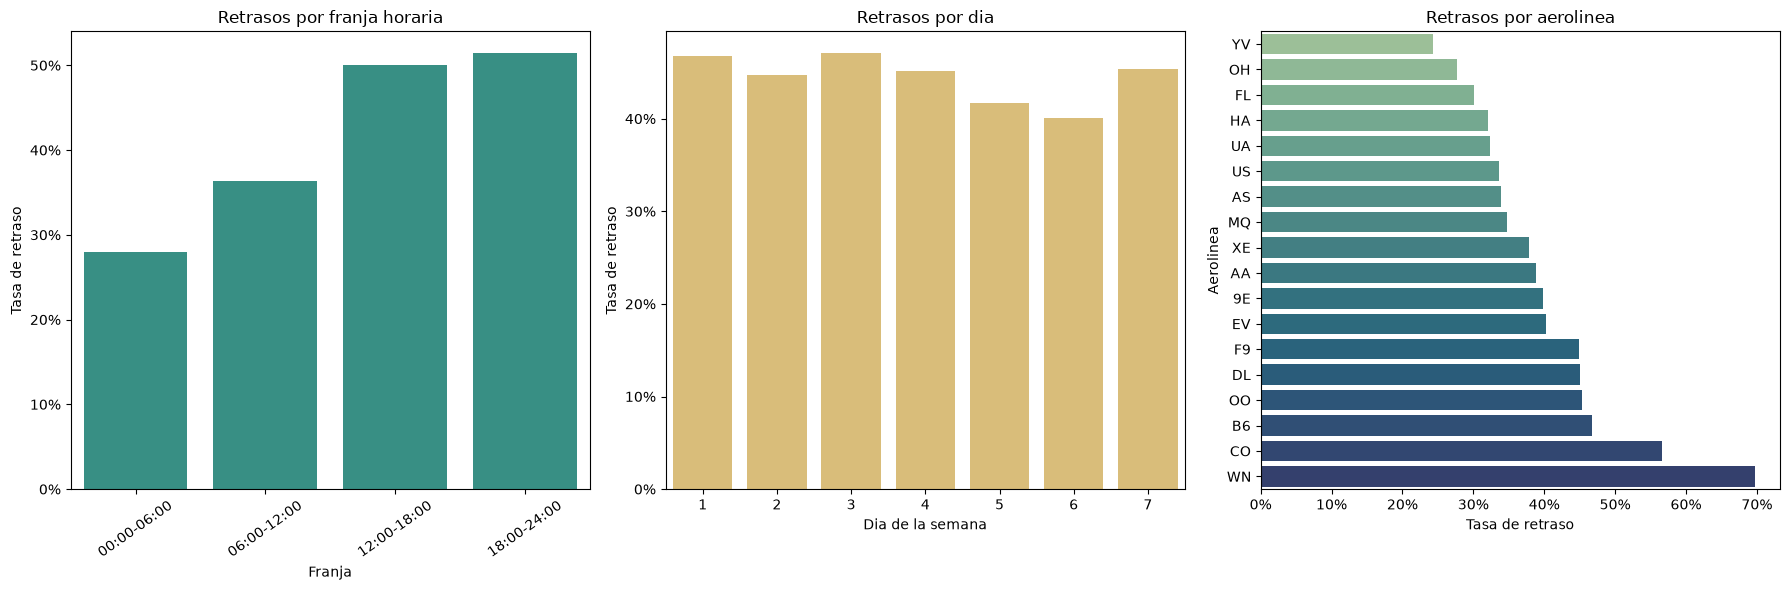

,Tasa,Retrasos,Vuelos
Airline,,,
WN,0.697759,65657,94097
DL,0.450476,27452,60940
OO,0.452899,22760,50254
AA,0.388470,17736,45656
MQ,0.348095,12742,36605


In [27]:
time_labels = ["00:00-06:00", "06:00-12:00", "12:00-18:00", "18:00-24:00"]
time_band = pd.cut(
    df["Time"],
    bins=[0, 360, 720, 1080, 1440],
    labels=time_labels,
    right=False,
)

delay_by_time = df.groupby(time_band, observed=True)["Delay"].mean()
delay_by_day = df.groupby("DayOfWeek")["Delay"].mean()
delay_by_airline = (
    df.groupby("Airline")["Delay"]
    .agg(Tasa="mean", Retrasos="sum", Vuelos="size")
    .query("Vuelos >= 1000")
    .sort_values("Tasa")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(
    x=delay_by_time.index,
    y=delay_by_time.values,
    color="#2A9D8F",
    ax=axes[0],
)
axes[0].set(title="Retrasos por franja horaria", xlabel="Franja", ylabel="Tasa de retraso")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    x=delay_by_day.index,
    y=delay_by_day.values,
    color="#E9C46A",
    ax=axes[1],
)
axes[1].set(title="Retrasos por dia", xlabel="Dia de la semana", ylabel="Tasa de retraso")

sns.barplot(
    x=delay_by_airline["Tasa"],
    y=delay_by_airline.index,
    hue=delay_by_airline.index,
    palette="crest",
    legend=False,
    ax=axes[2],
)
axes[2].set(title="Retrasos por aerolinea", xlabel="Tasa de retraso", ylabel="Aerolinea")

percent_formatter = plt.FuncFormatter(lambda value, _: f"{value:.0%}")
axes[0].yaxis.set_major_formatter(percent_formatter)
axes[1].yaxis.set_major_formatter(percent_formatter)
axes[2].xaxis.set_major_formatter(percent_formatter)

plt.tight_layout()
plt.show()

delay_by_airline.sort_values("Retrasos", ascending=False).head(5)

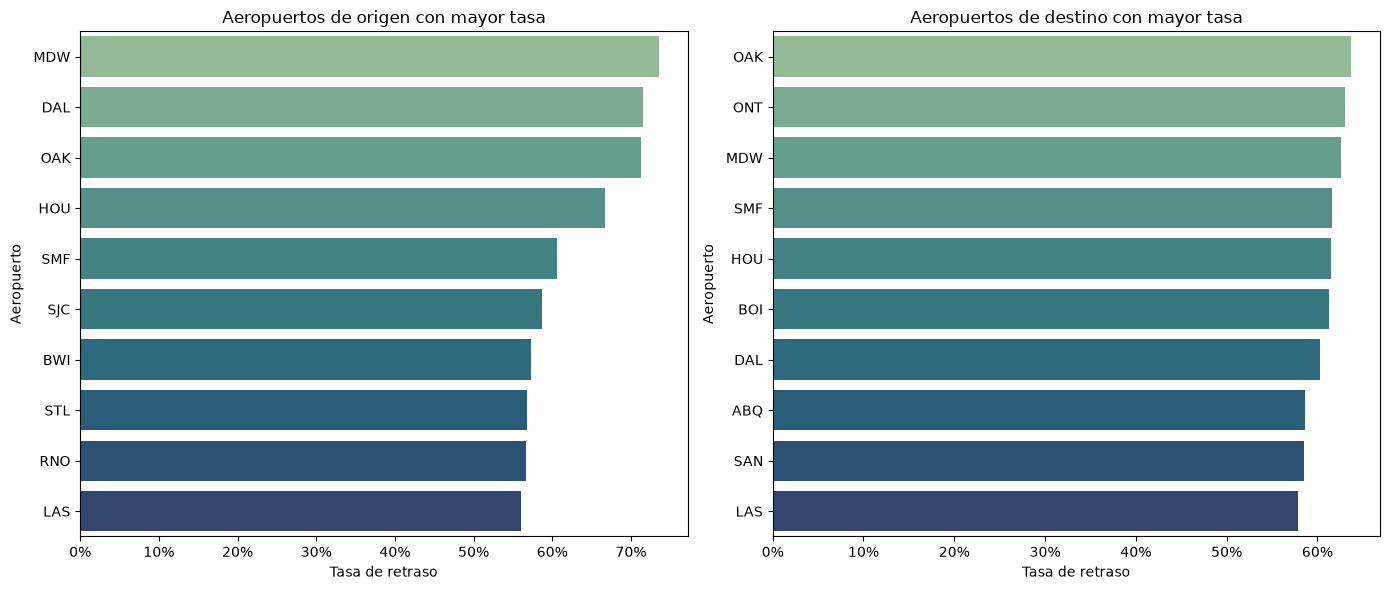

,Tasa,Retrasos,Vuelos
AirportFrom,,,
MDW,0.735182,5222,7103
DAL,0.715998,2748,3838
OAK,0.712926,2697,3783
HOU,0.667195,2949,4420
SMF,0.605879,2123,3504


,Tasa,Retrasos,Vuelos
AirportTo,,,
OAK,0.637133,2409,3781
ONT,0.630983,1226,1943
MDW,0.626021,4446,7102
SMF,0.615606,2138,3473
HOU,0.615524,2720,4419


In [28]:
def delay_summary(column):
    return (
        df.groupby(column)["Delay"]
        .agg(Tasa="mean", Retrasos="sum", Vuelos="size")
        .query("Vuelos >= 1000")
        .sort_values("Tasa", ascending=False)
    )

delay_by_origin = delay_summary("AirportFrom")
delay_by_destination = delay_summary("AirportTo")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for axis, data, title in zip(
    axes,
    [delay_by_origin.head(10), delay_by_destination.head(10)],
    ["Aeropuertos de origen con mayor tasa", "Aeropuertos de destino con mayor tasa"],
):
    sns.barplot(
        x=data["Tasa"],
        y=data.index,
        hue=data.index,
        palette="crest",
        legend=False,
        ax=axis,
    )
    axis.set(title=title, xlabel="Tasa de retraso", ylabel="Aeropuerto")
    axis.xaxis.set_major_formatter(percent_formatter)

plt.tight_layout()
plt.show()

display(delay_by_origin.head(5))
display(delay_by_destination.head(5))

### Hallazgos del análisis de relaciones

- La correlación entre `Time` y `Delay` es positiva pero débil ($r=0.150$): los vuelos programados más tarde tienden a presentar más retrasos, aunque `Time` por sí sola no explica la variable objetivo.
- `Length` presenta una relación lineal muy baja con `Delay` ($r=0.040$), y `Time` prácticamente no se relaciona linealmente con `Length` ($r=-0.021$).
- La tasa de retraso aumenta durante el día: 27.93% entre 00:00 y 06:00, 36.36% entre 06:00 y 12:00, 50.09% entre 12:00 y 18:00 y 51.44% entre 18:00 y 24:00. Esto demuestra asociación, pero no permite establecer una causa.
- El día 3 presenta la mayor tasa de retraso (47.08%) y el día 6 la menor (40.06%). La variación por día es menor que la observada por franja horaria y aerolínea.
- Entre aerolíneas con al menos 1,000 vuelos, `WN` tiene la mayor tasa de retraso (69.78%), seguida por `CO` (56.62%); `YV` presenta la menor (24.29%). Por cantidad de retrasos lideran `WN`, `DL`, `OO`, `AA` y `MQ`.
- Entre aeropuertos con al menos 1,000 vuelos, `MDW` presenta la mayor tasa como origen (73.52%) y `OAK` la mayor como destino (63.71%). Estas asociaciones pueden estar relacionadas también con la aerolínea y la ruta.
- Las tasas por categorías describen asociaciones con `Delay`, no correlaciones lineales ni relaciones causales. `Airline`, `Time`, `DayOfWeek`, `AirportFrom` y `AirportTo` son candidatas para el modelado posterior.

## 6. Conclusiones de la exploración

- **Calidad de datos:** El dataset contiene 539,383 registros y 8 variables. Se encontraron 216,618 filas repetidas (40.16%), pero no deben eliminarse automáticamente porque no existe una fecha completa ni un identificador único que permita confirmar que sean vuelos duplicados.
- **Variables con nulos:** No se encontraron valores nulos, por lo que no será necesario aplicar técnicas de imputación.
- **Outliers detectados:** `Time` no presenta valores atípicos. En `Length` hay 25,650 vuelos por encima de 283.5 minutos que parecen plausibles y deben conservarse; únicamente los 4 registros con duración igual a cero requieren tratamiento durante la limpieza.
- **Variables más relacionadas:** `Time` muestra la mayor correlación lineal con `Delay`, aunque es débil ($r=0.150$). Las tasas evidencian asociaciones más marcadas con la franja horaria, la aerolínea, el día y los aeropuertos de origen y destino.
- **Posibles transformaciones:** Se recomienda crear franjas horarias o una representación cíclica de `Time`, codificar las variables categóricas y tratar `Flight` como identificador categórico de alta cardinalidad. El escalamiento dependerá del modelo seleccionado.
- **Variables candidatas:** `Airline`, `Time`, `DayOfWeek`, `AirportFrom` y `AirportTo` son las principales candidatas. `Length` puede conservarse inicialmente para comprobar su aporte, mientras que `Flight` deberá evaluarse antes de incluirse. La distribución de `Delay` es suficientemente equilibrada para comenzar sin remuestreo.

## 7. Limpieza y preparación para el modelado

- Tratamiento de duraciones inválidas
- Revisión de duplicados
- Codificación de variables categóricas
- Escalamiento según el modelo
- Ingeniería de características